In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [4]:
# 1. Load the data, skipping the second descriptive row
income_df = pd.read_csv('data\ACSST5Y2024.S1901-Data.csv', skiprows=[1])

# 2. Keep only the columns we need: GEO_ID and Median Income
# Column S1901_C01_012E = Estimate!!Households!!Median income
income_df = income_df[['GEO_ID', 'S1901_C01_012E']].copy()

# 3. Rename for clarity
income_df.columns = ['geo_id', 'median_income']

# 4. Extract the 5-digit Zip Code from GEO_ID (e.g., '8600000US10001' -> '10001')
income_df['zip_code'] = income_df['geo_id'].str.split('US').str[-1]

# 5. Convert income to numeric (removes non-number strings like "-" or "250,000+")
income_df['median_income'] = pd.to_numeric(income_df['median_income'], errors='coerce')

# Drop rows where we don't have income data
income_df = income_df.dropna(subset=['median_income'])

print(f"Loaded income data for {len(income_df)} Zip Codes.")
income_df.head()

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\David\AppData\Local\Temp\ipykernel_23036\3617178258.py:2: SyntaxWarning: invalid escape sequence '\A'
  income_df = pd.read_csv('data\ACSST5Y2024.S1901-Data.csv', skiprows=[1])


Loaded income data for 1617 Zip Codes.


,geo_id,median_income,zip_code
0,860Z200US06390,98125.0,06390
1,860Z200US10001,129852.0,10001
2,860Z200US10002,48386.0,10002
3,860Z200US10003,154262.0,10003
5,860Z200US10005,190233.0,10005


In [5]:
# Load the tree data (You can start with 2nd parameter nrows=10000 to test, then remove nrows later)
trees_df = pd.read_csv('data/2015_Street_Tree_Census_-_Tree_Data_20260315.csv')

# 1. Filter to only 'Alive' trees (we can't measure the health of a stump)
trees_df = trees_df[trees_df['status'] == 'Alive']

# 2. Keep only the relevant columns
trees_df = trees_df[['tree_id', 'health', 'postcode', 'spc_common', 'borough']]

# 3. Ensure Zip Code (postcode) is a string to match the income data
trees_df['postcode'] = trees_df['postcode'].astype(str)

print(f"Loaded {len(trees_df)} living trees.")
trees_df.head()

Loaded 652173 living trees.


,tree_id,health,postcode,spc_common,borough
0,180683,Fair,11375,red maple,Queens
1,200540,Fair,11357,pin oak,Queens
2,204026,Good,11211,honeylocust,Brooklyn
3,204337,Good,11211,honeylocust,Brooklyn
4,189565,Good,11215,American linden,Brooklyn


In [6]:
# 1. Count how many trees are in each Zip Code
tree_counts = trees_df.groupby('postcode')['tree_id'].count().reset_index()
tree_counts.columns = ['zip_code', 'tree_count']

# 2. Calculate "Health Score"
# We map Good=3, Fair=2, Poor=1 to turn categories into a math average
health_map = {'Good': 3, 'Fair': 2, 'Poor': 1}
trees_df['health_numeric'] = trees_df['health'].map(health_map)

avg_health = trees_df.groupby('postcode')['health_numeric'].mean().reset_index()
avg_health.columns = ['zip_code', 'avg_health_score']

# 3. Merge tree stats together
tree_stats = pd.merge(tree_counts, avg_health, on='zip_code')

# 4. FINAL MERGE: Link Tree Stats with Income!
final_df = pd.merge(tree_stats, income_df, on='zip_code')

print("Final Combined Dataset Created!")
final_df.head()

Final Combined Dataset Created!


,zip_code,tree_count,avg_health_score,geo_id,median_income
0,10001,850,2.809412,860Z200US10001,129852.0
1,10002,2158,2.714087,860Z200US10002,48386.0
2,10003,1943,2.709213,860Z200US10003,154262.0
3,10005,130,2.346154,860Z200US10005,190233.0
4,10006,48,2.875000,860Z200US10006,190170.0


In [7]:
# Z-Score filter for outliers
from scipy import stats
import numpy as np

# Remove Zip Codes with very few trees (e.g., less than 50)
filtered_df = final_df[final_df['tree_count'] > 50].copy()

# Filter out extreme income outliers (more than 3 standard deviations away)
z_scores = np.abs(stats.zscore(filtered_df['median_income']))
clean_df = filtered_df[z_scores < 3]

print(f"Removed {len(final_df) - len(clean_df)} outlier Zip Codes.")

Removed 4 outlier Zip Codes.


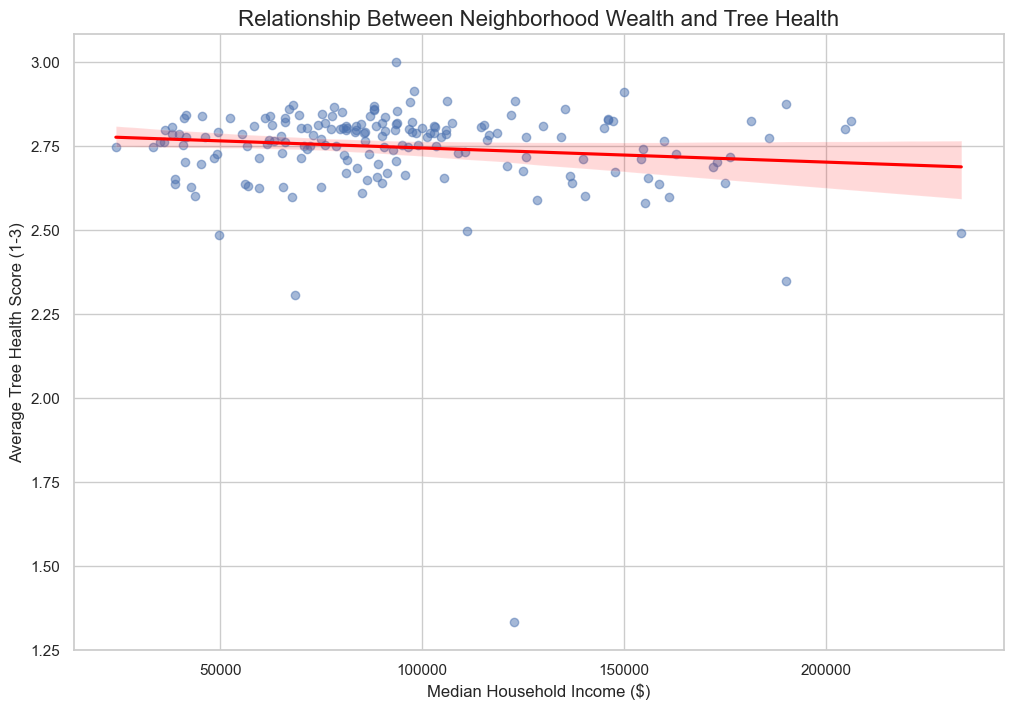

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot with a regression line
plt.figure(figsize=(12, 8))
sns.regplot(data=final_df, x='median_income', y='avg_health_score', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship Between Neighborhood Wealth and Tree Health', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Average Tree Health Score (1-3)', fontsize=12)

plt.show()

In [9]:
# Calculate the correlation matrix
correlation = final_df['median_income'].corr(final_df['avg_health_score'])

print(f"The Correlation between Income and Tree Health is: {correlation:.2f}")

if correlation > 0.3:
    print("Result: There is a moderate to strong positive relationship!")
elif correlation > 0:
    print("Result: There is a weak positive relationship.")
else:
    print("Result: There is no positive relationship found yet.")

The Correlation between Income and Tree Health is: -0.12
Result: There is no positive relationship found yet.


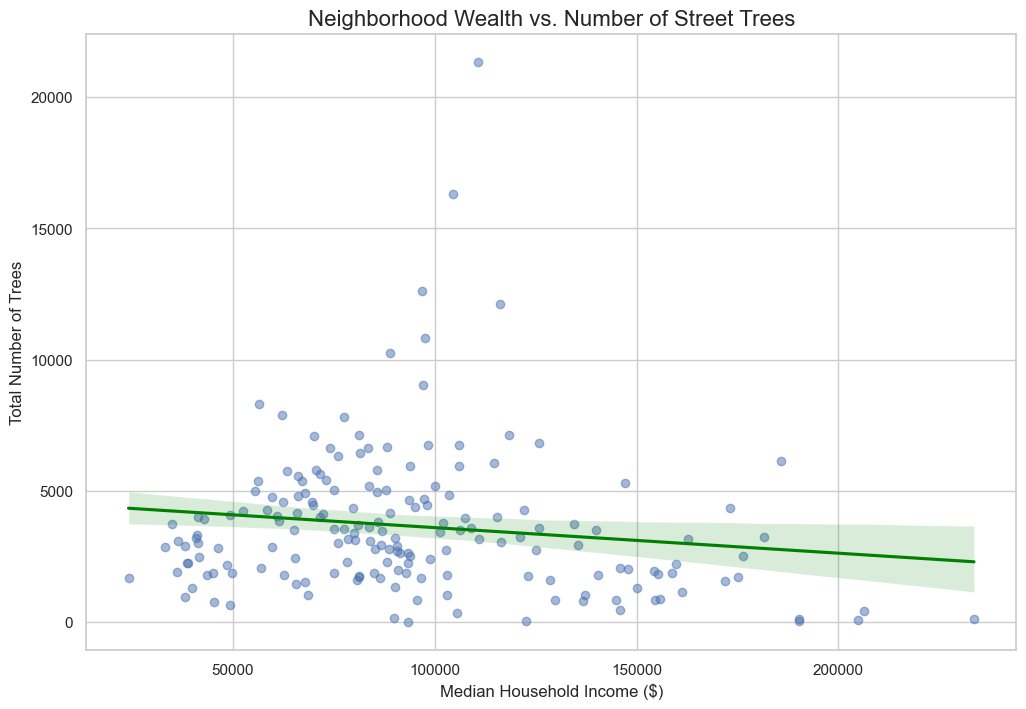

In [10]:
# Scatter plot for Income vs. Total Tree Count
plt.figure(figsize=(12, 8))
sns.regplot(data=final_df, x='median_income', y='tree_count', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})

plt.title('Neighborhood Wealth vs. Number of Street Trees', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Total Number of Trees', fontsize=12)

plt.show()

<Axes: xlabel='median_income', ylabel='percent_good'>

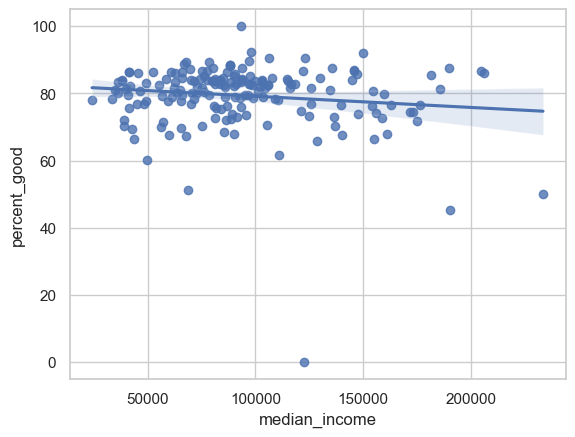

In [11]:
# Go back to trees_df and calculate % of 'Good' trees
health_counts = trees_df.groupby(['postcode', 'health']).size().unstack(fill_value=0)
health_counts['total'] = health_counts.sum(axis=1)
health_counts['percent_good'] = (health_counts['Good'] / health_counts['total']) * 100

# Merge this back into your final_df
final_df = final_df.merge(health_counts[['percent_good']], left_on='zip_code', right_index=True)

# Now plot Income vs Percent Good
sns.regplot(data=final_df, x='median_income', y='percent_good')

In [12]:
# We haven't found a correlations so far...
# Analyzing the whole city at once mixes concrete jungles (Manhattan) with garden boroughs (Queens). Lets try splitting the scatter plot by Borough.

# --- STEP 1: ADD BOROUGH INFO ---
# Create the lookup from the original trees_df 
zip_to_borough = trees_df.groupby('postcode')['borough'].first().reset_index()
zip_to_borough.columns = ['zip_code', 'borough']

# Merge it into final_df
if 'borough' not in final_df.columns:
    final_df = final_df.merge(zip_to_borough, on='zip_code', how='left')

# --- STEP 2: CREATE THE CLEAN VERSION ---
# We remove Zip Codes with < 20 trees and income outliers
from scipy import stats
import numpy as np

# 1. Filter by tree count
clean_df = final_df[final_df['tree_count'] > 20].copy()

# 2. Filter by Income (removing top/bottom 1% or using Z-score)
z_scores = np.abs(stats.zscore(clean_df['median_income']))
clean_df = clean_df[z_scores < 3]

print(f"Cleaned data ready. Using {len(clean_df)} neighborhoods out of {len(final_df)}.")

# --- STEP 3: BOROUGH CORRELATION ---
print("\n--- Correlation by Borough (Wealth vs. % Good Health) ---")
for borough in clean_df['borough'].dropna().unique():
    subset = clean_df[clean_df['borough'] == borough]
    # We need at least a few data points to calculate correlation
    if len(subset) > 5:
        corr = subset['median_income'].corr(subset['percent_good'])
        print(f"{borough:15} | Correlation: {corr:+.2f} | Zip Codes: {len(subset)}")

# In the Bronx, we have a correlation of +0.46, which is statistically significant
# This suggests that in the Bronx, private investment or local stewardship could be related to socioeconomic status

Cleaned data ready. Using 176 neighborhoods out of 178.

--- Correlation by Borough (Wealth vs. % Good Health) ---
Manhattan       | Correlation: -0.01 | Zip Codes: 39
Staten Island   | Correlation: -0.08 | Zip Codes: 12
Bronx           | Correlation: +0.46 | Zip Codes: 25
Queens          | Correlation: +0.04 | Zip Codes: 62
Brooklyn        | Correlation: -0.05 | Zip Codes: 38


In [13]:
# This calculates the correlation for EACH borough separately
for borough in clean_df['borough'].unique():
    subset = clean_df[clean_df['borough'] == borough]
    corr = subset['median_income'].corr(subset['percent_good'])
    print(f"Correlation in {borough}: {corr:.2f}")

Correlation in Manhattan: -0.01
Correlation in Staten Island: -0.08
Correlation in Bronx: 0.46
Correlation in Queens: 0.04
Correlation in Brooklyn: -0.05


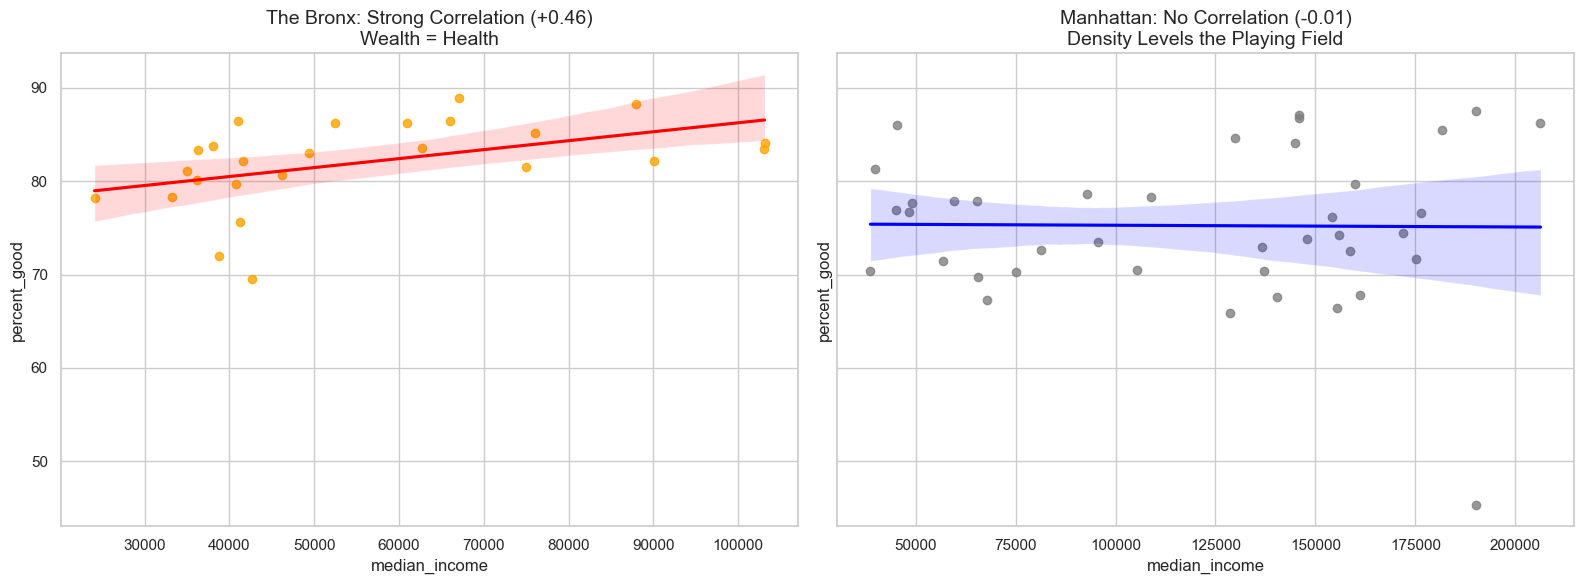

In [14]:
# Create a side-by-side comparison of the Bronx and Manhattan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: The Bronx (The Strong Link)
bronx_data = clean_df[clean_df['borough'] == 'Bronx']
sns.regplot(data=bronx_data, x='median_income', y='percent_good', 
            ax=ax1, color='orange', line_kws={'color':'red'})
ax1.set_title(f'The Bronx: Strong Correlation (+0.46)\nWealth = Health', fontsize=14)

# Plot 2: Manhattan (The Concrete Jungle)
manhattan_data = clean_df[clean_df['borough'] == 'Manhattan']
sns.regplot(data=manhattan_data, x='median_income', y='percent_good', 
            ax=ax2, color='gray', line_kws={'color':'blue'})
ax2.set_title(f'Manhattan: No Correlation (-0.01)\nDensity Levels the Playing Field', fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
species_diversity = (trees_df.groupby('postcode')['spc_common'].nunique().reset_index())
species_diversity.columns = ['zip_code', 'species_diversity']
species_diversity.head()

,zip_code,species_diversity
0,10001,33
1,10002,73
2,10003,59
3,10004,11
4,10005,9


In [16]:
final_df = final_df.merge(species_diversity, on='zip_code', how='left')
print(final_df.nlargest(10, 'species_diversity')[['zip_code', 'borough', 'tree_count', 'species_diversity']])

    zip_code        borough  tree_count  species_diversity
50     10312  Staten Island       21356                124
45     10306  Staten Island       12616                122
51     10314  Staten Island       16330                122
130    11357         Queens        9017                120
120    11234       Brooklyn       10838                118
146    11375         Queens        6742                117
131    11358         Queens        6674                116
150    11385         Queens       10262                116
95     11208       Brooklyn        7896                113
44     10305  Staten Island        6635                112


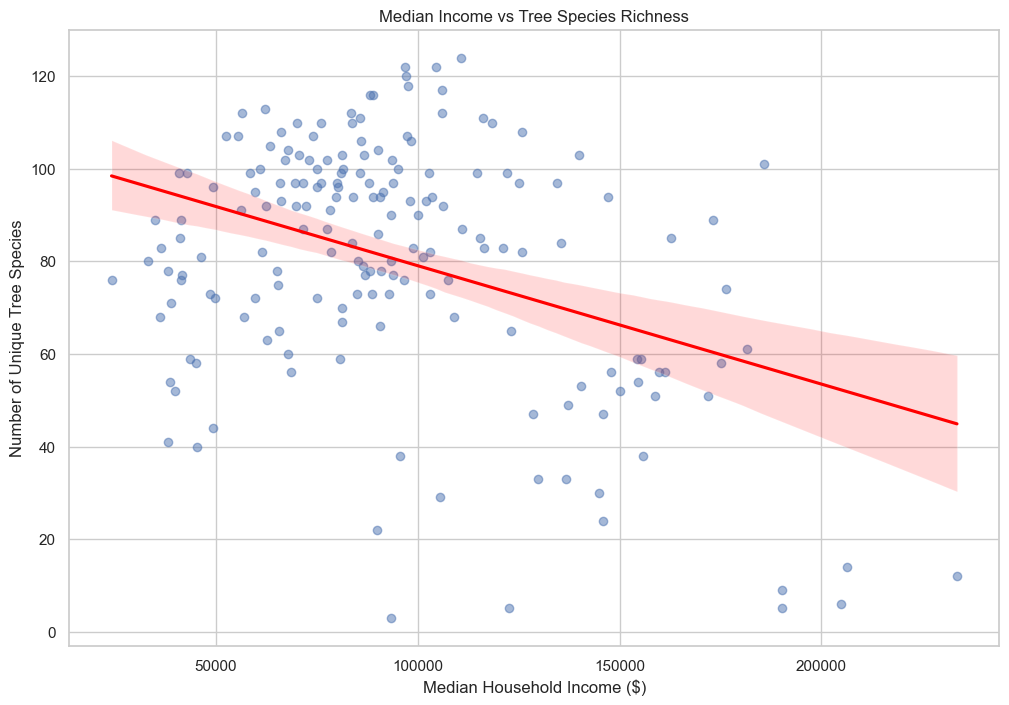

Correlation between income and species richness: -0.39


In [17]:
plt.figure(figsize=(12, 8))
sns.regplot(
    data=final_df,
    x='median_income',
    y='species_diversity',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('Median Income vs Tree Species Richness')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Number of Unique Tree Species')
plt.show()

corr = final_df['median_income'].corr(final_df['species_diversity'])
print(f"Correlation between income and species richness: {corr:.2f}")

In [18]:
zip_to_borough = trees_df.groupby('postcode')['borough'].first().reset_index()
zip_to_borough.columns = ['zip_code', 'borough']

if 'borough' not in final_df.columns:
    final_df = final_df.merge(zip_to_borough, on='zip_code', how='left')

# Calculate average and standard deviation of tree counts
mean_trees = final_df['tree_count'].mean()
std_trees = final_df['tree_count'].std()

# Keep zip codes with tree counts close to the average
close_avg_df = final_df[
    (final_df['tree_count'] >= mean_trees - std_trees) &
    (final_df['tree_count'] <= mean_trees + std_trees)
].copy()

print(f"Average tree count: {mean_trees:.2f}")
print(f"Standard deviation: {std_trees:.2f}")

print("\nCorrelation by Borough: Income vs Species Richness")
for borough in close_avg_df['borough'].dropna().unique():
    subset = close_avg_df[close_avg_df['borough'] == borough]
    
    if len(subset) > 5:
        corr = subset['median_income'].corr(subset['species_diversity'])
        print(f"{borough} Correlation: {corr:+.2f}")

Average tree count: 3652.21
Standard deviation: 2781.30

Correlation by Borough: Income vs Species Richness
Manhattan Correlation: -0.42
Staten Island Correlation: -0.20
Bronx Correlation: +0.21
Queens Correlation: -0.10
Brooklyn Correlation: +0.16


In [19]:
# Group by species and calculate stats
species_health_df = trees_df.groupby('spc_common').agg(
    tree_count=('tree_id', 'count'),
    avg_health_score=('health_numeric', 'mean')
).reset_index()

# Keep only species with a large enough sample so tiny groups don't distort things
species_health_df = species_health_df[species_health_df['tree_count'] >= 500]

# Sort by health score
species_health_df = species_health_df.sort_values(by='avg_health_score', ascending=False)

print(species_health_df.head(15))

              spc_common  tree_count  avg_health_score
107         sawtooth oak        2244          2.855169
28      Japanese zelkova       29258          2.837480
96               pin oak       53185          2.833336
82           honeylocust       64263          2.829575
131           willow oak        3184          2.824749
120             sweetgum       10657          2.823872
71      eastern redcedar        1101          2.823797
112        silver linden        7995          2.821764
31      London planetree       87014          2.817259
14           Chinese elm        5345          2.810477
29   Kentucky coffeetree        3364          2.802319
19           English oak        1644          2.802311
76       golden raintree        3719          2.801022
60                cherry       29279          2.793094
110          shingle oak        1049          2.791230


In [20]:
# Group by borough + species
species_borough_health = trees_df.groupby(['borough', 'spc_common']).agg(
    tree_count=('tree_id', 'count'),
    avg_health_score=('health_numeric', 'mean')
).reset_index()

# Keep only borough-species combos with enough trees
species_borough_health = species_borough_health[species_borough_health['tree_count'] >= 200]

print(species_borough_health.head())

  borough              spc_common  tree_count  avg_health_score
0   Bronx  'Schubert' chokecherry         575          2.742609
2   Bronx            American elm        1471          2.767505
4   Bronx       American hornbeam         295          2.637288
6   Bronx         American linden        2132          2.765478
8   Bronx            Amur maackia         466          2.759657


In [21]:
for borough in species_borough_health['borough'].unique():
    print(f"\n--- Top species in {borough} ---")
    top_species = species_borough_health[species_borough_health['borough'] == borough] \
        .sort_values(by='avg_health_score', ascending=False)
    
    print(top_species[['spc_common', 'tree_count', 'avg_health_score']].head(10))


--- Top species in Bronx ---
           spc_common  tree_count  avg_health_score
107      sawtooth oak         363          2.898072
120          sweetgum         904          2.886062
131        willow oak         505          2.877228
41       Siberian elm         392          2.869898
82        honeylocust        9691          2.867609
19        English oak         223          2.865471
12       Callery pear        4947          2.855670
96            pin oak        6445          2.851202
38     Schumard's oak         261          2.831418
28   Japanese zelkova        4638          2.825787

--- Top species in Brooklyn ---
              spc_common  tree_count  avg_health_score
160     Japanese zelkova        9659          2.849777
144         Callery pear        9081          2.836141
151          English oak         559          2.831843
228              pin oak       12343          2.829377
252             sweetgum        2027          2.828318
203     eastern redcedar         29

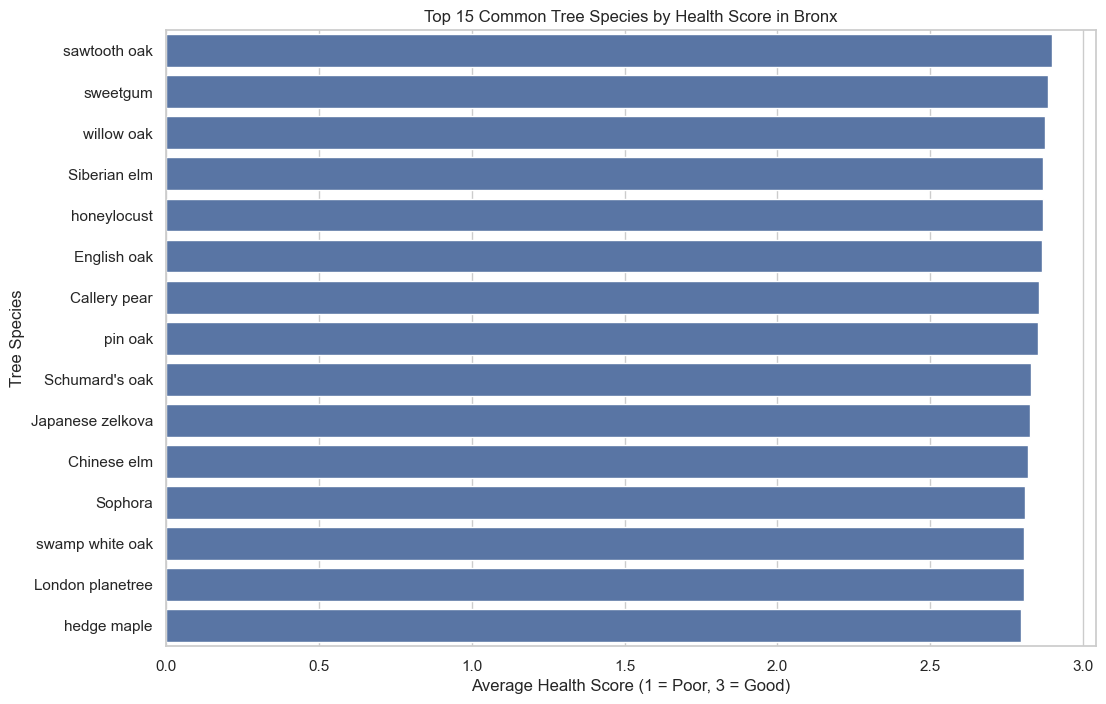

In [22]:
borough_name = 'Bronx'   # change this to Queens, Manhattan, Brooklyn, Staten Island

borough_data = species_borough_health[
    species_borough_health['borough'] == borough_name
].sort_values(by='avg_health_score', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=borough_data, x='avg_health_score', y='spc_common')

plt.title(f'Top 15 Common Tree Species by Health Score in {borough_name}')
plt.xlabel('Average Health Score (1 = Poor, 3 = Good)')
plt.ylabel('Tree Species')
plt.show()

In [28]:
# Average health of each species within each zip code
species_zip_health = trees_df.groupby(['postcode', 'spc_common']).agg(
    tree_count=('tree_id', 'count'),
    avg_health_score=('health_numeric', 'mean'),
    borough=('borough', 'first')
).reset_index()

species_zip_health = species_zip_health.rename(columns={'postcode': 'zip_code'})

# Merge with income
species_income_df = pd.merge(
    species_zip_health,
    income_df[['zip_code', 'median_income']],
    on='zip_code',
    how='inner'
)

print("\nCorrelation: Income vs Species Health Within Each Borough")

for borough in species_income_df['borough'].dropna().unique():
    print(f"\n=== {borough} ===")
    
    borough_subset = species_income_df[species_income_df['borough'] == borough]
    
    # Loop through species in this borough
    for species in borough_subset['spc_common'].unique():
        species_subset = borough_subset[borough_subset['spc_common'] == species]
        
        # Need enough zip codes for correlation to mean anything
        if len(species_subset) >= 10:
            corr = species_subset['median_income'].corr(species_subset['avg_health_score'])
            print(f"{species:25} | Correlation: {corr:+.2f} | Zip Codes: {len(species_subset)}")


Correlation: Income vs Species Health Within Each Borough

=== Manhattan ===
'Schubert' chokecherry    | Correlation: +0.12 | Zip Codes: 31
American elm              | Correlation: -0.32 | Zip Codes: 37
American hophornbeam      | Correlation: +0.35 | Zip Codes: 21
American linden           | Correlation: -0.07 | Zip Codes: 38
Amur maple                | Correlation: -0.27 | Zip Codes: 14
Callery pear              | Correlation: -0.34 | Zip Codes: 40
Chinese elm               | Correlation: -0.28 | Zip Codes: 35
English oak               | Correlation: -0.23 | Zip Codes: 36
European hornbeam         | Correlation: -0.05 | Zip Codes: 24
Japanese zelkova          | Correlation: -0.10 | Zip Codes: 38
Kentucky coffeetree       | Correlation: +0.03 | Zip Codes: 35
London planetree          | Correlation: -0.35 | Zip Codes: 38
Sophora                   | Correlation: -0.22 | Zip Codes: 38
black oak                 | Correlation: +0.31 | Zip Codes: 34
cherry                    | Correlation:

c:\Users\David\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\David\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


bald cypress              | Correlation: +0.02 | Zip Codes: 37
black cherry              | Correlation: -0.08 | Zip Codes: 32
black locust              | Correlation: +0.12 | Zip Codes: 35
black maple               | Correlation: +0.33 | Zip Codes: 13
black oak                 | Correlation: +0.14 | Zip Codes: 35
black walnut              | Correlation: -0.11 | Zip Codes: 20
catalpa                   | Correlation: +0.14 | Zip Codes: 28
cherry                    | Correlation: -0.26 | Zip Codes: 38
common hackberry          | Correlation: +0.03 | Zip Codes: 37
crab apple                | Correlation: -0.00 | Zip Codes: 38
crimson king maple        | Correlation: +0.08 | Zip Codes: 36
cucumber magnolia         | Correlation: -0.43 | Zip Codes: 20
dawn redwood              | Correlation: -0.05 | Zip Codes: 38
eastern cottonwood        | Correlation: +0.19 | Zip Codes: 20
eastern redbud            | Correlation: -0.03 | Zip Codes: 36
eastern redcedar          | Correlation: +0.14 | Zip Co

In [29]:
corr_data = []

for borough in species_income_df['borough'].dropna().unique():
    borough_subset = species_income_df[species_income_df['borough'] == borough]
    
    for species in borough_subset['spc_common'].unique():
        species_subset = borough_subset[borough_subset['spc_common'] == species]
        
        if len(species_subset) >= 10:
            corr = species_subset['median_income'].corr(
                species_subset['avg_health_score']
            )
            corr_data.append([borough, species, corr])

In [30]:
corr_df = pd.DataFrame(corr_data, columns=['borough', 'species', 'correlation'])

heatmap_df = corr_df.pivot(index='species', columns='borough', values='correlation')

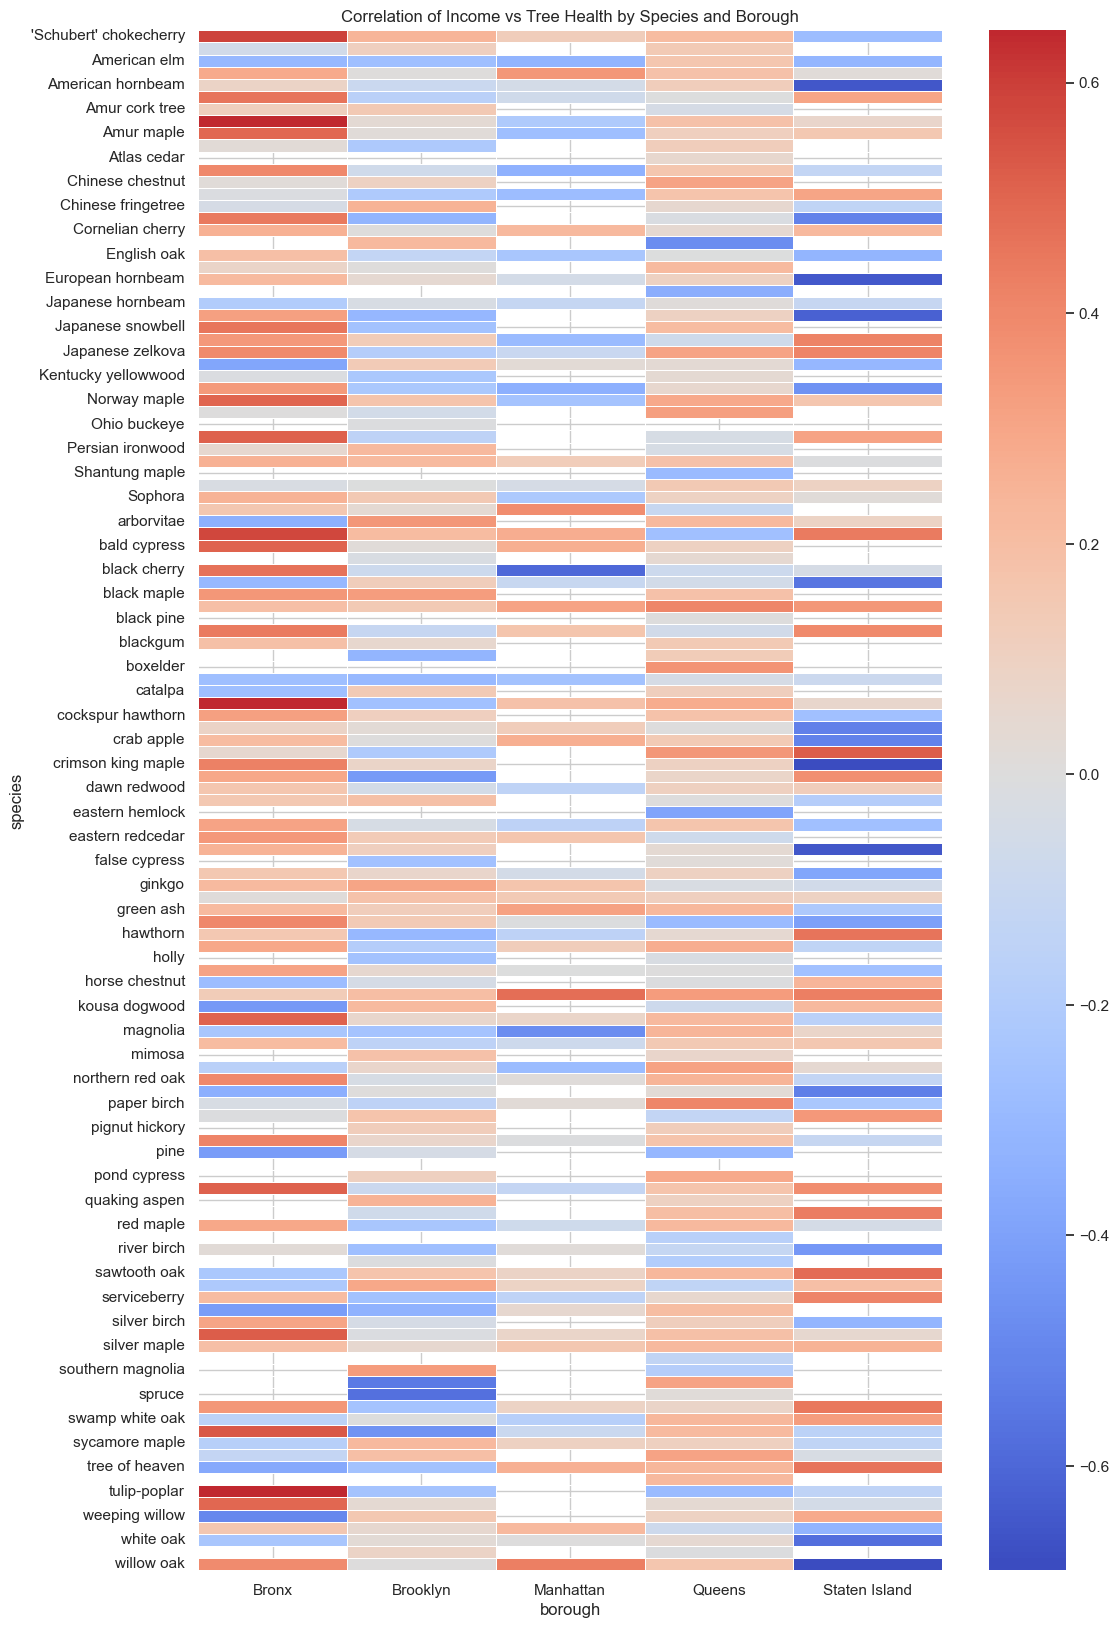

In [31]:
plt.figure(figsize=(12, 20))

sns.heatmap(
    heatmap_df,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation of Income vs Tree Health by Species and Borough')
plt.show()